In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score

import warnings
warnings.filterwarnings('ignore')
import shap
import joblib

In [3]:
#loading the dataset
df = pd.read_csv(r'C:\Users\indur\OneDrive\Desktop\power bi projects\Public_Transport_Delay\feature_engineering.csv')
df


#drop columns 

df = df.drop(columns=['Unnamed: 0'])

In [4]:
#feature and target 

x = df.drop(columns='DELAY_MINUTES',axis=1)
y = df['DELAY_MINUTES']


In [5]:

numerical_features = x.select_dtypes(include=['float64','int64']).columns
categorical_features = x.select_dtypes(include=['object']).columns

In [7]:


# preprocessing numerical columns

num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaling',StandardScaler())
])

cat_pipeline = Pipeline([

    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

#column transform 

preprocessor = ColumnTransformer([

    ('num_cols',num_pipeline,numerical_features),
    ('cat_col',cat_pipeline,categorical_features)
])

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:

# baseline model pipeline 

liner_pipeline = Pipeline([

    ('preprocessing',preprocessor),
    ('model',LinearRegression())
])

#random forest pipeline

random_pipeline = Pipeline([

    ('preprocessing',preprocessor),
    ('model',RandomForestRegressor(random_state=42))
])


In [10]:

# cross validation linear regression


print('\n LINEAR REGRESSION CROSS VALIDATION')
random_cross_val = cross_val_score(liner_pipeline,x_train,y_train,cv=5,scoring='r2')
print('cross_val_score:',random_cross_val)
print('mean_cross_val_score:',random_cross_val.mean())

# cross validation random forest 
print('\n RANDOM FOREST REGRESSION CROSS VALITATION')

cross_val_score = cross_val_score(random_pipeline,x_train,y_train,cv=5,scoring='r2')
print('cross_val_score_random_forest:',cross_val_score)
print('mean_cross_val_score_random_forest:',cross_val_score.mean())
print()


 LINEAR REGRESSION CROSS VALIDATION
cross_val_score: [0.04770097 0.05255693 0.04558856 0.05036354 0.0507581 ]
mean_cross_val_score: 0.0493936189259407

 RANDOM FOREST REGRESSION CROSS VALITATION
cross_val_score_random_forest: [ 0.01001983  0.01420799  0.00059128 -0.00246403  0.00940602]
mean_cross_val_score_random_forest: 0.006352215891314783



In [11]:
# hyperparameter tuning

param_grid = {
    'model__n_estimators':[100,200],
    'model__max_depth':[5,10,None]
}
grid_search = GridSearchCV(random_pipeline,param_grid,cv=5,scoring='r2')
grid_search.fit(x_train,y_train)
print('best parameters:',grid_search.best_params_)
best_model = grid_search.best_estimator_

print(best_model)


best parameters: {'model__max_depth': 5, 'model__n_estimators': 200}
Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_cols',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  Index(['CITY', 'ROUTE_ID', 'HOUR', 'DAY_OF_WEEK', 'RAINFALL_MM', 'TEMPERATURE',
       'HUMIDITY', 'WIND_SPEED', 'RUSH_HOUR', 'TRAFFIC_LEVEL', 'EVENT_TODAY',
       'EVENT_TYPE', 'IS_WEEKEND', 'VEHICLE_TYPE', 'AVG_DELAY_PER_CITY',
       'AVG_DELAY_PER_TRAFFIC_LEVEL', 'HUMIDITY_TEMP_RATIO'],
      dtype='object')),
                                                 ('cat_col',
                                                  Pipeline(st

In [12]:

#prediction A

liner_pipeline.fit(x_train,y_train)
y_pred_A = liner_pipeline.predict(x_test)

print(y_pred_A)


#Evaluation  for A
print('\n LINEAR REGRESSION EVALUATION')


mae_lr =  mean_absolute_error(y_test,y_pred_A)
print('mean_absolute_error:',mae_lr)
rmse_lr = root_mean_squared_error(y_test,y_pred_A)
print('root_mean_squared_error:',rmse_lr)
r2_lr = r2_score(y_test,y_pred_A)
print('r2_score:',r2_lr)

[45.95458498 15.68342154 35.30357118 ... 41.21567149 45.76674683
 16.94698178]

 LINEAR REGRESSION EVALUATION
mean_absolute_error: 42.42657357770844
root_mean_squared_error: 54.558084691998395
r2_score: 0.04662936850588739


In [13]:
y_pred_B = random_pipeline.fit(x_train,y_train)
y_pre = random_pipeline.predict(x_test)

In [14]:
#prediction B

y_pred_B = best_model.predict(x_test)
print(y_pred_B)

# evaluation for B


mae_rf = mean_absolute_error(y_test,y_pred_B)
print('mean_absolute_error:',mae_rf)
rmse_rf =  root_mean_squared_error(y_test,y_pred_B)
print('root_mean_squared_error:',rmse_rf)
r2_rf = r2_score(y_test,y_pred_B)
print('r2_score:',r2_rf)

[46.25708208 18.16480089 35.96004513 ... 40.16896127 44.15380843
 18.07946494]
mean_absolute_error: 42.44759550914853
root_mean_squared_error: 54.603090383425986
r2_score: 0.045055823465927625


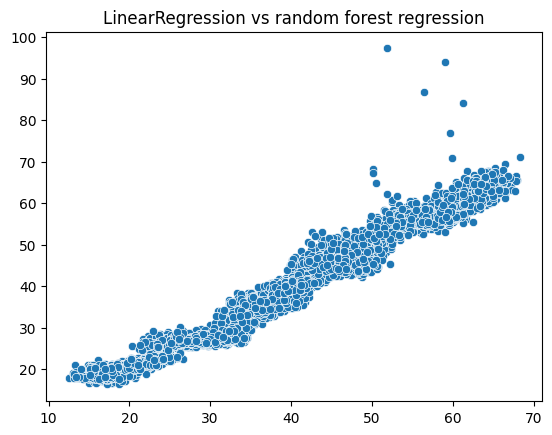

In [15]:
sns.scatterplot(x = y_pred_A,y=y_pred_B)
plt.title('LinearRegression vs random forest regression')
plt.show()

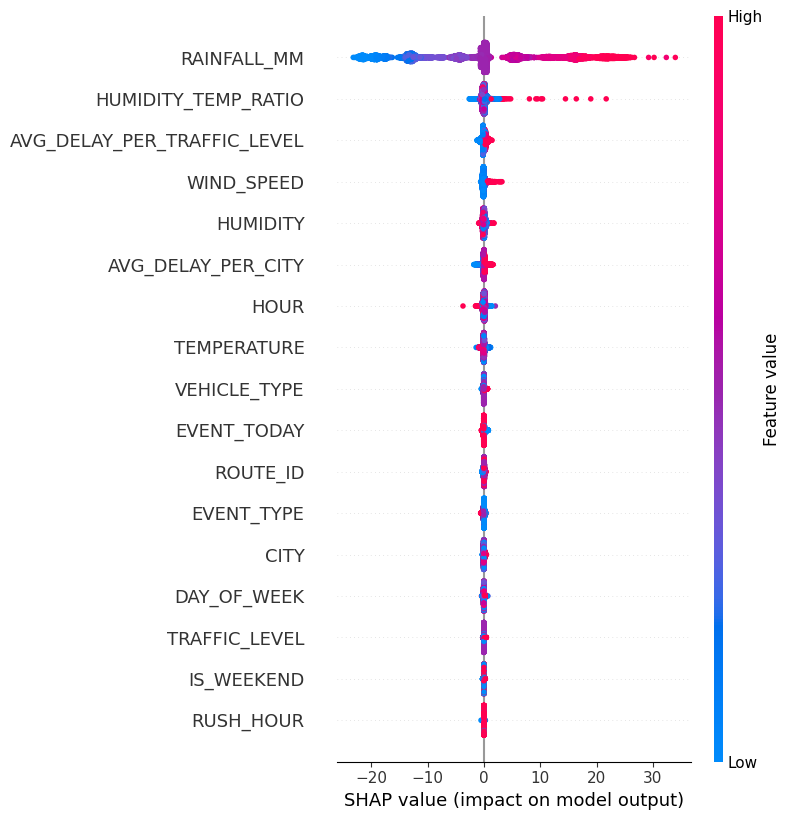

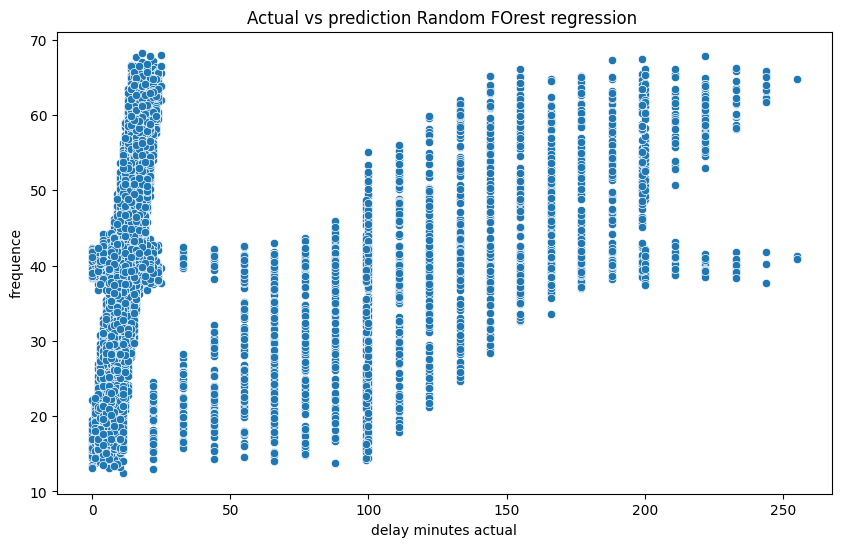

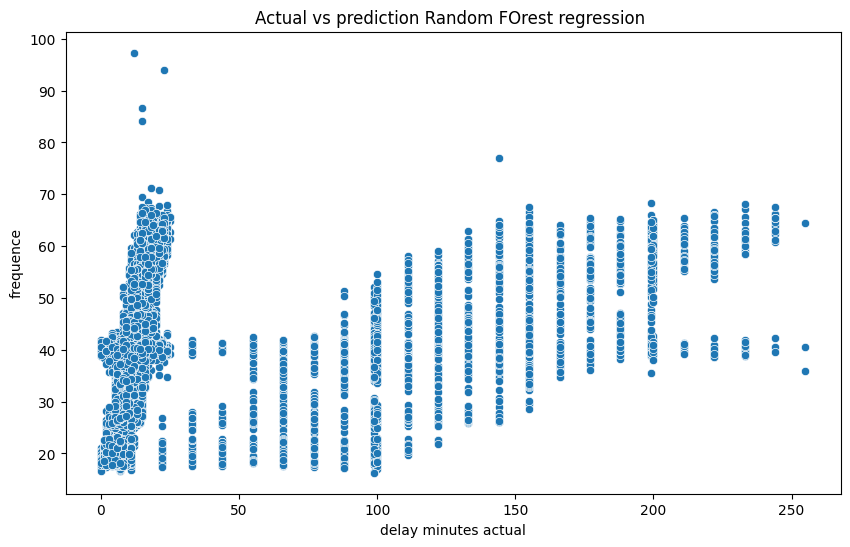

In [16]:

# SHAP EXPLAINABILITY

X_processed = best_model.named_steps['preprocessing'].transform(x_test)

model = best_model.named_steps['model']

explainer = shap.Explainer(model)
shap_values = explainer(X_processed)

shap.summary_plot(shap_values,X_processed,feature_names= x.columns)





#vislualization 

plt.figure(figsize=(10,6))
sns.scatterplot(x = y_test,y =y_pred_A,)
plt.title('Actual vd prediction for liner regression')
plt.title('Actual vs prediction Random FOrest regression ') 
plt.xlabel('delay minutes actual')
plt.ylabel('frequence')
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x = y_test,y =y_pred_B,)
plt.title('Actual vs prediction Random FOrest regression ') 
plt.xlabel('delay minutes actual')
plt.ylabel('frequence')
plt.show()



In [17]:
#result dataframe for A 

result = x_test.copy()
result['actual'] = y_test.values
result['prediction_A'] = y_pred_A
print(result.head())


       CITY  ROUTE_ID  HOUR  DAY_OF_WEEK  RAINFALL_MM  TEMPERATURE  HUMIDITY  \
37979     5       5.0    17            6          6.3         36.0      86.6   
9911      3       5.0     3            6          0.1         36.0      85.0   
43386     1       1.0    23            3          4.2         34.0      65.5   
13822     4       3.0    21            3          5.0         27.0      50.0   
44810     3       3.0    16            3          5.0         36.0      73.0   

       WIND_SPEED  RUSH_HOUR  TRAFFIC_LEVEL  EVENT_TODAY  EVENT_TYPE  \
37979         5.0          1            2.0            1         2.0   
9911         77.0          1            3.0            1         1.0   
43386        11.0          1            1.0            1         1.0   
13822         8.0          1            2.0            0         1.0   
44810         6.0          1            2.0            0         1.0   

       IS_WEEKEND  VEHICLE_TYPE  AVG_DELAY_PER_CITY  \
37979           0             1

In [18]:
#result actual vs prediction for B

result1 = x_test.copy()
result1['actual'] = y_test.values
result1['prediction_B'] = y_pred_B
print(result1.head())

       CITY  ROUTE_ID  HOUR  DAY_OF_WEEK  RAINFALL_MM  TEMPERATURE  HUMIDITY  \
37979     5       5.0    17            6          6.3         36.0      86.6   
9911      3       5.0     3            6          0.1         36.0      85.0   
43386     1       1.0    23            3          4.2         34.0      65.5   
13822     4       3.0    21            3          5.0         27.0      50.0   
44810     3       3.0    16            3          5.0         36.0      73.0   

       WIND_SPEED  RUSH_HOUR  TRAFFIC_LEVEL  EVENT_TODAY  EVENT_TYPE  \
37979         5.0          1            2.0            1         2.0   
9911         77.0          1            3.0            1         1.0   
43386        11.0          1            1.0            1         1.0   
13822         8.0          1            2.0            0         1.0   
44810         6.0          1            2.0            0         1.0   

       IS_WEEKEND  VEHICLE_TYPE  AVG_DELAY_PER_CITY  \
37979           0             1

In [19]:

A_B_comparsion = pd.DataFrame({

    'model':['LinearRegression','RandomForestRegressor'],
    'MBE':[mae_lr,mae_rf],
    'RMSE':[rmse_lr,rmse_rf],
    'r2_score':[r2_lr,r2_rf]
})

print(A_B_comparsion)

                   model        MBE       RMSE  r2_score
0       LinearRegression  42.426574  54.558085  0.046629
1  RandomForestRegressor  42.447596  54.603090  0.045056


In [20]:
# A/B testing

if r2_rf > r2_lr:
    print(f'RandomForestRegressor performs better the linear regression:{r2_rf}')
else:

    print(f'linear regression performs better than the random forest regression:{r2_lr}') 

linear regression performs better than the random forest regression:0.04662936850588739


In [21]:
joblib.dump(liner_pipeline,'linear_model.pkl') 
joblib.dump(random_pipeline,'random_forest_model.pkl')

['random_forest_model.pkl']